In [6]:
from mlwpy import *

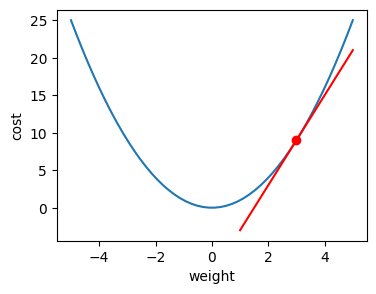

In [7]:
xs = np.linspace(-5,5)
ys = xs**2
fig, ax = plt.subplots(figsize=(4,3))
ax.plot(xs, ys)
# better Python:
# pt = co.namedtuple('Point', ['x', 'y'])(3,3**2)
pt_x, pt_y = 3, 3**2
ax.plot(pt_x, pt_y, 'ro')
line_xs = pt_x + np.array([-2, 2])
# line ys = mid_point + (x amount) * slope_of_line
# one step right gets one "slope of line" increase in that line's up
line_ys = 3**2 + (line_xs - pt_x) * (2 * pt_x)
ax.plot(line_xs, line_ys, 'r-')
ax.set_xlabel('weight')
ax.set_ylabel('cost');

Approximate location of blue graph minimum: 0.0029296875


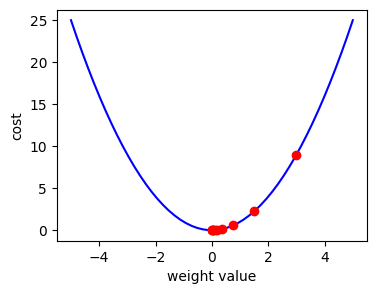

In [8]:
weights = np.linspace(-5, 5)
costs = weights**2

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(weights, costs, 'b')

# Current best guess at the minimum
weight_min = 3

# Follow the path downhill from our starting point
for i in range(10):
    # Cost at current guess
    cost_at_min = weight_min**2
    ax.plot(weight_min, cost_at_min, 'ro')

    # Slope at current guess (derivative)
    slope_at_min = 2 * weight_min

    # Update guess using gradient descent
    step_size = 0.25
    weight_min = weight_min - step_size * slope_at_min

ax.set_xlabel('weight value')
ax.set_ylabel('cost')
print("Approximate location of blue graph minimum:", weight_min)


In [9]:
from scipy.optimize import fmin as magical_minimum_finder
def f(x):
    return x**2
magical_minimum_finder(f, [3], disp=False)

array([-0.])

In [10]:
linreg_ftrs_p1 = np.c_[np.arange(10), np.ones(10)] # +1 trick in data
true_wgts = m,b = w_1, w_0 = 3,2
linreg_tgt = rdot(true_wgts, linreg_ftrs_p1)
linreg_table = pd.DataFrame(linreg_ftrs_p1,
columns=['ftr_1', 'ones'])
linreg_table['tgt'] = linreg_tgt
linreg_table[:3]

,ftr_1,ones,tgt
0,0.0000,1.0000,2.0000
1,1.0000,1.0000,5.0000
2,2.0000,1.0000,8.0000


In [11]:
def linreg_model(weights, ftrs):
    return rdot(weights, ftrs)

def linreg_loss(predicted, actual):
    errors = predicted - actual
    return np.dot(errors, errors)  # sum-of-squares

def no_penalty(weights):
    return 0.0


In [12]:
def make_cost(ftrs, tgt, model_func, loss_func, c_tradeoff, complexity_penalty):
    # Build an optimization problem from data, model, loss, penalty
    def cost(weights):
        return (loss_func(model_func(weights, ftrs), tgt) +
                c_tradeoff * complexity_penalty(weights))
    return cost


In [13]:
# Build linear regression optimization problem
linreg_cost = make_cost(
    linreg_ftrs_p1, linreg_tgt,
    linreg_model, linreg_loss,
    0.0, no_penalty
)

learned_wgts = magical_minimum_finder(linreg_cost, [5, 5], disp=False)

print(" true weights:", true_wgts)
print("learned weights:", learned_wgts)


 true weights: (3, 2)
learned weights: [3. 2.]


In [14]:
def L1_penalty(weights):
    return np.abs(weights).sum()
def L2_penalty(weights):
    return np.dot(weights, weights)

In [15]:
# Linear regression with L1 regularization (lasso regression)
linreg_L1_pen_cost = make_cost(
    linreg_ftrs_p1, linreg_tgt,
    linreg_model, linreg_loss,
    1.0, L1_penalty
)

learned_wgts = magical_minimum_finder(linreg_L1_pen_cost, [5, 5], disp=False)

print(" true weights:", true_wgts)
print("learned weights:", learned_wgts)


 true weights: (3, 2)
learned weights: [3.0212 1.8545]


In [16]:
# Linear regression with L2 regularization (ridge regression)
linreg_L2_pen_cost = make_cost(
    linreg_ftrs_p1, linreg_tgt,
    linreg_model, linreg_loss,
    1.0, L2_penalty
)

learned_wgts = magical_minimum_finder(linreg_L2_pen_cost, [5, 5], disp=False)

print(" true weights:", true_wgts)
print("learned weights:", learned_wgts)


 true weights: (3, 2)
learned weights: [3.0508 1.6102]


In [17]:
logreg_ftr = np.random.uniform(5, 15, size=(100,))
true_wgts = m, b = -2, 20

line_of_logodds = m * logreg_ftr + b
prob_at_x = np.exp(line_of_logodds) / (1 + np.exp(line_of_logodds))

logreg_tgt = np.random.binomial(1, prob_at_x, len(logreg_ftr))
logreg_ftrs_p1 = np.c_[logreg_ftr, np.ones_like(logreg_ftr)]

logreg_table = pd.DataFrame(logreg_ftrs_p1, columns=['ftr_1', 'ones'])
logreg_table['tgt'] = logreg_tgt

display(logreg_table.head())


,ftr_1,ones,tgt
0,8.7454,1.0000,1
1,14.5071,1.0000,0
2,12.3199,1.0000,0
3,10.9866,1.0000,0
4,6.5602,1.0000,1


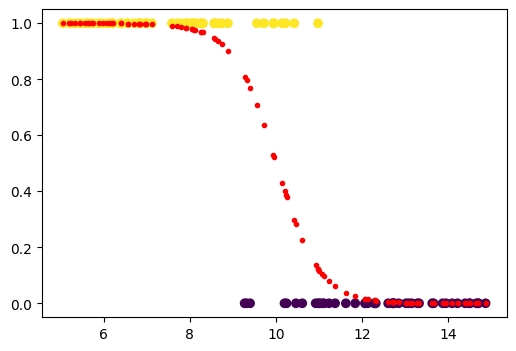

In [18]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(logreg_ftr, prob_at_x, 'r.')
ax.scatter(logreg_ftr, logreg_tgt, c=logreg_tgt);

In [19]:
# For logistic regression
def logreg_model(weights, ftrs):
    return rdot(weights, ftrs)

def logreg_loss_01(predicted, actual):
    # sum(-actual * log(predicted) - (1 - actual) * log(1 - predicted))
    # for 0/1 targets, simplifies to:
    return np.sum(-predicted * actual + np.log(1 + np.exp(predicted)))


In [20]:
logreg_cost = make_cost(
    logreg_ftrs_p1, logreg_tgt,
    logreg_model, logreg_loss_01,
    0.0, no_penalty
)

learned_wgts = magical_minimum_finder(logreg_cost, [5, 5], disp=False)

print(" true weights:", true_wgts)
print("learned weights:", learned_wgts)


 true weights: (-2, 20)
learned weights: [-1.9774 19.8659]


In [21]:
# Logistic regression with penalty
logreg_pen_cost = make_cost(
    logreg_ftrs_p1, logreg_tgt,
    logreg_model, logreg_loss_01,
    0.5, L1_penalty
)

learned_wgts = magical_minimum_finder(logreg_pen_cost, [5, 5], disp=False)

print(" true weights:", true_wgts)
print("learned weights:", learned_wgts)


 true weights: (-2, 20)
learned weights: [-1.2809 12.7875]


In [22]:
def binary_to_pm1(b):
    # Map {0,1} or {False,True} to {-1, +1}
    return (b * 2) - 1

binary_to_pm1(0), binary_to_pm1(1)


(-1, 1)

In [23]:
# For logistic regression with +1/-1 targets
def logreg_model(weights, ftrs):
    return rdot(weights, ftrs)

def logreg_loss_pm1(predicted, actual):
    # -actual * log(predicted) - (1 - actual) * log(1 - predicted)
    # For +1/-1 targets, this simplifies to:
    return np.sum(np.log(1 + np.exp(-predicted * actual)))


In [24]:
logreg_cost = make_cost(
    logreg_ftrs_p1, binary_to_pm1(logreg_tgt),
    logreg_model, logreg_loss_pm1,
    0.0, no_penalty
)

learned_wgts = magical_minimum_finder(logreg_cost, [5, 5], disp=False)

print(" true weights:", true_wgts)
print("learned weights:", learned_wgts)


 true weights: (-2, 20)
learned weights: [-1.9774 19.8659]


In [25]:
def predict_with_logreg_weights_to_pm1(w_hat, x):
    prob = 1 / (1 + np.exp(rdot(w_hat, x)))
    thresh = prob < .5
    return binary_to_pm1(thresh)
preds = predict_with_logreg_weights_to_pm1(learned_wgts, logreg_ftrs_p1)
print(metrics.accuracy_score(preds, binary_to_pm1(logreg_tgt)))

0.93


In [26]:
# For SVC
def hinge_loss(predicted, actual):
    hinge = np.maximum(1 - predicted * actual, 0.0)
    return np.sum(hinge)

def predict_with_svm_weights(w_hat, x):
    return np.sign(rdot(w_hat, x)).astype(int)


In [27]:
svm_ftrs = logreg_ftrs_p1
svm_tgt = binary_to_pm1(logreg_tgt) # svm "demands" +/- 1
# svm model is "just" rdot, so we don't define it separately now
svc_cost = make_cost(svm_ftrs, svm_tgt, rdot,
hinge_loss, 0.0, no_penalty)
learned_weights = magical_minimum_finder(svc_cost, [5,5], disp=False)
preds = predict_with_svm_weights(learned_weights, svm_ftrs)
print('no penalty accuracy:',
metrics.accuracy_score(preds, svm_tgt))

no penalty accuracy: 0.91


In [28]:
# svc with penalty
svc_pen_cost = make_cost(svm_ftrs, svm_tgt, rdot,
hinge_loss, 1.0, L1_penalty)
learned_weights = magical_minimum_finder(svc_pen_cost, [5,5], disp=False)
preds = predict_with_svm_weights(learned_weights, svm_ftrs)
print('accuracy with penalty:',
metrics.accuracy_score(preds, svm_tgt))

accuracy with penalty: 0.91


In [30]:
import keras.layers as kl
import keras.models as km
import keras.optimizers as ko

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
def Keras_LinearRegression(n_ftrs):
    model = km.Sequential()
    # Dense layer includes bias by default (i.e., +1 trick)
    model.add(kl.Dense(1,
                       activation='linear',
                       input_dim=n_ftrs))
    model.compile(optimizer=ko.SGD(learning_rate=0.01), loss='mse')
    return model


In [ ]:
def Keras_LinearRegression(n_ftrs):
    model = km.Sequential()
    model.add(kl.Input(shape=(n_ftrs,)))  # Properly define input shape
    model.add(kl.Dense(1, activation='linear'))  # No need for input_dim here
    model.compile(optimizer=ko.SGD(learning_rate=0.01), loss='mse')
    return model


In [ ]:
# For various reasons, we let Keras handle the +1 trick
# So we will *not* send the `ones` feature
linreg_ftrs = linreg_ftrs_p1[:, 0].reshape(-1, 1)  # Reshape for Keras

linreg_nn = Keras_LinearRegression(1)
history = linreg_nn.fit(linreg_ftrs, linreg_tgt, epochs=1000, verbose=0)

preds = linreg_nn.predict(linreg_ftrs)
mse = metrics.mean_squared_error(preds, linreg_tgt)

print("Training MSE: {:5.4f}".format(mse))


In [ ]:
history.history['loss'][:5]

In [ ]:
def Keras_LogisticRegression(n_ftrs):
    model = km.Sequential()
    model.add(kl.Input(shape=(n_ftrs,)))  # modern input declaration
    model.add(kl.Dense(1, activation='sigmoid'))
    model.compile(optimizer=ko.SGD(), loss='binary_crossentropy')
    return model

logreg_ftr_reshaped = logreg_ftr.reshape(-1, 1)  # reshape for Keras input

logreg_nn = Keras_LogisticRegression(1)
history = logreg_nn.fit(logreg_ftr_reshaped, logreg_tgt, epochs=1000, verbose=0)

# Output is a probability
preds = logreg_nn.predict(logreg_ftr_reshaped) > 0.5
print('accuracy:', metrics.accuracy_score(preds, logreg_tgt))


In [ ]:
import pymc3 as pm
# getting really hard to convince toolkits to be less verbose

In [ ]:
import logging
pymc3_log = logging.getLogger('pymc3')
pymc3_log.setLevel(2**20)

In [ ]:
with pm.Model() as model:
    # Prior distributions
    sd = pm.HalfNormal('sd', sd=1)
    intercept = pm.Normal('Intercept', mu=0, sd=20)
    ftr_1_wgt = pm.Normal('ftr_1_wgt', mu=0, sd=20)

    # Linear model: y = m*x + b
    preds = ftr_1_wgt * linreg_table['ftr_1'] + intercept

    # Likelihood: target values with Gaussian noise around predictions
    target = pm.Normal('tgt', mu=preds, sd=sd, observed=linreg_table['tgt'])

    # Sample posterior with reduced verbosity
    linreg_trace = pm.sample(1000, progressbar=False, compute_convergence_checks=False)


In [ ]:
pm.summary(linreg_trace)[['mean']]

In [ ]:
with pm.Model() as model:
    pm.glm.GLM.from_formula('tgt ~ ftr_1', linreg_table, family=pm.glm.families.Normal())
    linreg_trace = pm.sample(5000, progressbar=False, compute_convergence_checks=False)

pm.summary(linreg_trace)[['mean']]


In [ ]:
%%capture
# Workaround for a problem: writing to a tmp file.
%matplotlib qt

fig, axes = plt.subplots(3, 2, figsize=(12, 6))
axes = pm.traceplot(linreg_trace, ax=axes)

for ax in axes[:, -1]:
    ax.set_visible(False)

plt.gcf().savefig('outputs/work-around.png')


In [ ]:
Image('outputs/work-around.png', width=800, height=2400)

In [ ]:
with pm.Model() as model:
    pm.glm.GLM.from_formula('tgt ~ ftr_1', logreg_table, family=pm.glm.families.Binomial())
    logreg_trace = pm.sample(10000, progressbar=False, compute_convergence_checks=False)

pm.summary(logreg_trace)[['mean']]


In [ ]:
%matplotlib inline

df_trace = pm.trace_to_dataframe(logreg_trace)

sns.jointplot(
    x='ftr_1',
    y='Intercept',
    data=df_trace,
    kind='kde',
    height=4
)


In [ ]:
from keras.utils import to_categorical as k_to_categorical

def Keras_MultiLogisticRegression(n_ftrs, n_classes):
    model = km.Sequential()
    model.add(kl.Input(shape=(n_ftrs,)))  # modern input shape
    model.add(kl.Dense(n_classes, activation='softmax'))
    model.compile(optimizer=ko.SGD(), loss='categorical_crossentropy')
    return model

logreg_nn2 = Keras_MultiLogisticRegression(1, 2)

# Reshape input for Keras and convert targets to one-hot
logreg_ftr_reshaped = logreg_ftr.reshape(-1, 1)
logreg_tgt_cat = k_to_categorical(logreg_tgt)

history = logreg_nn2.fit(logreg_ftr_reshaped, logreg_tgt_cat, epochs=1000, verbose=0)

# Predict returns class probabilities; use argmax to get predicted labels
preds = logreg_nn2.predict(logreg_ftr_reshaped).argmax(axis=1)

print(metrics.accuracy_score(logreg_tgt, preds))
